# Plasma-Sheet Modeling

This results demonstration is adapted from *Machine Learning Modeling of
Earth's Plasma Sheet using Multi-Spacecraft Observations*, a manuscript
currently under review. The broader study uses decades of Geotail and
Magnetospheric Multiscale observations to investigate how data selection,
model design, and spacecraft coverage affect statistical descriptions of
plasma-sheet density and temperature.

PRIME stands for **Probabilistic Regressor for Input to the
Magnetosphere Estimation**. The original
[PRIME model](https://www.frontiersin.org/journals/astronomy-and-space-sciences/articles/10.3389/fspas.2023.1250779/full)
uses the time history measured by monitors at L1 to predict near-Earth
solar-wind conditions together with their uncertainties. PRIME-SH
extends this data-driven probabilistic approach to the magnetosheath.
PRIME-PS applies the broader modeling family to plasma-sheet density and
ion temperature using multi-spacecraft observations.

The [PRIME GitHub repository](https://github.com/connor-obrien888/prime)
provides code for working with the solar-wind, magnetosheath, and
plasma-sheet models. This page focuses only on saved PRIME-PS results;
it does not define or train the model.

We load versioned saved outputs and ask two questions:

1. How do PRIME-PS and the analytical TM03 model compare on the same
   chronological ion-temperature test samples?
2. Under one high-density, northward-IMF driving condition, what spatial
   structure do their equatorial density maps produce?

## Runtime dependency check

In [1]:
import importlib.util

REQUIRED_RUNTIME = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
}
missing = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    raise RuntimeError(
        "Missing notebook dependencies: " + ", ".join(missing) + ". "
        "Locally run `uv sync --group notebooks`; these packages are "
        "normally available in Google Colab."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

In [3]:
import hashlib
import json
import os
from pathlib import Path
from urllib.parse import quote
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATASET_ID = "plasma-sheet-prime-tm03"
DATASET_FILES = {
    "plasma_sheet_prime_tm03_results.npz": (
        "data/plasma-sheet-prime-tm03/plasma_sheet_prime_tm03_results.npz",
        "ed9392dcdc305f0275459efb52e3fd15e80fd0be9b76b7a1816b5177cf2ba604",
    ),
    "manifest.json": (
        "data/plasma-sheet-prime-tm03/manifest.json",
        "f845dd71a644bcf08c591df39431f08b6c6a5f33577e782e2e8f29030bbecadc",
    ),
}


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def resolve_dataset_file(filename, relative_path, expected_sha256):
    candidates = []
    override = os.getenv("HELIO_DATA_DIR")
    if override:
        root = Path(override).expanduser()
        candidates.extend([root / DATASET_ID / filename, root / filename])
    for root in [Path.cwd(), *Path.cwd().parents]:
        candidates.append(root / relative_path)
    cache = (
        Path(os.getenv(
            "HELIO_DATA_CACHE",
            Path.home() / ".cache" / "helio-data-methods",
        ))
        / "datasets"
        / DATASET_ID
        / filename
    )
    candidates.append(cache)

    for candidate in candidates:
        if candidate.is_file() and file_sha256(candidate) == expected_sha256:
            return candidate

    cache.parent.mkdir(parents=True, exist_ok=True)
    ref = os.getenv("HELIO_DATA_REF", "main")
    url = (
        "https://raw.githubusercontent.com/SavvasRaptis/helio-data-methods/"
        f"{quote(ref, safe='')}/{quote(relative_path, safe='/')}"
    )
    try:
        with urlopen(url, timeout=60) as response, cache.open("wb") as output:
            output.write(response.read())
    except Exception as exc:
        cache.unlink(missing_ok=True)
        raise RuntimeError(
            "The plasma-sheet results could not be downloaded. Check network "
            "access or set HELIO_DATA_DIR to a directory containing the "
            f"{DATASET_ID} files."
        ) from exc
    if file_sha256(cache) != expected_sha256:
        cache.unlink(missing_ok=True)
        raise ValueError(
            f"Checksum mismatch for {filename}; the invalid file was removed."
        )
    return cache


resolved = {
    filename: resolve_dataset_file(filename, relative_path, checksum)
    for filename, (relative_path, checksum) in DATASET_FILES.items()
}
bundle_path = resolved["plasma_sheet_prime_tm03_results.npz"]
manifest = json.loads(resolved["manifest.json"].read_text(encoding="utf-8"))
bundle_sha256 = file_sha256(bundle_path)
if manifest["bundle"]["sha256"] != bundle_sha256:
    raise ValueError("The dataset manifest and result-bundle checksums disagree")
results = np.load(bundle_path, allow_pickle=False)

## 1. Chronological ion-temperature comparison

Both models are evaluated on the same timestamps. TM03 has missing output
for some chronological test rows, so a common finite mask leaves 46,595
samples. This avoids giving either model a different evaluation population.

In [4]:
observed = results["temperature_observed_kev"]
predictions = {
    "PRIME-PS": results["temperature_prime_ps_kev"],
    "TM03": results["temperature_tm03_kev"],
}
timestamps = results["timestamp_ns"]
if len(observed) != 46_595 or not all(len(values) == len(observed) for values in predictions.values()):
    raise ValueError("Unexpected chronological sample count")


def regression_metrics(y_true, y_pred):
    return {
        "mae_kev": float(mean_absolute_error(y_true, y_pred)),
        "rmse_kev": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
        "pearson_r": float(np.corrcoef(y_true, y_pred)[0, 1]),
    }


# Evaluate both models on the same chronological sample population.
metrics = {
    model: regression_metrics(observed, predicted)
    for model, predicted in predictions.items()
}
print(f"common chronological samples: {len(observed):,}")
print(f"observations above the displayed 12 keV limit: {(observed > 12).sum():,}")
for model, values in metrics.items():
    print(
        f"{model:8s} | MAE {values['mae_kev']:.3f} keV | "
        f"RMSE {values['rmse_kev']:.3f} keV | R2 {values['r2']:.3f} | "
        f"r {values['pearson_r']:.3f}"
    )

common chronological samples: 46,595
observations above the displayed 12 keV limit: 102
PRIME-PS | MAE 1.220 keV | RMSE 1.615 keV | R2 0.388 | r 0.704
TM03     | MAE 1.357 keV | RMSE 1.763 keV | R2 0.271 | r 0.556


### Compare the temperature predictions

Both panels use the same axes and count scale. This makes the spread, systematic offsets, and behavior at high ion temperature easy to compare.

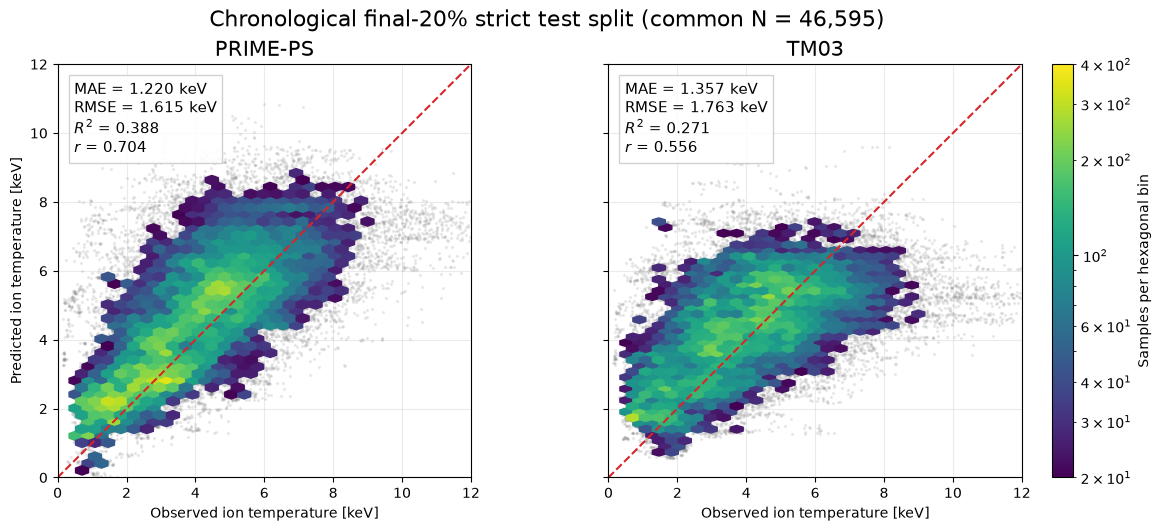

In [5]:
figure, axes = plt.subplots(
    1, 2, figsize=(12.2, 5.2), sharex=True, sharey=True,
    constrained_layout=True,
)
count_norm = LogNorm(vmin=20, vmax=400)  # Share one logarithmic count scale.
hexbin = None

for axis, (model, predicted) in zip(axes, predictions.items()):
    axis.scatter(
        observed, predicted, s=2, color="0.50", alpha=0.12,
        rasterized=True, zorder=1,
    )
    hexbin = axis.hexbin(
        observed, predicted, gridsize=48, mincnt=20,
        cmap="viridis", norm=count_norm, zorder=2,
    )
    axis.plot([0, 12], [0, 12], "--", color="#d62728", linewidth=1.5)
    values = metrics[model]
    metric_text = (
        f"MAE = {values['mae_kev']:.3f} keV\n"
        f"RMSE = {values['rmse_kev']:.3f} keV\n"
        f"$R^2$ = {values['r2']:.3f}\n"
        f"$r$ = {values['pearson_r']:.3f}"
    )
    axis.text(
        0.04, 0.96, metric_text, transform=axis.transAxes,
        va="top", fontsize=11,
        bbox={"facecolor": "white", "edgecolor": "0.8", "alpha": 0.9},
    )
    axis.set_title(model, fontsize=15)
    axis.set_xlabel("Observed ion temperature [keV]")
    axis.set_xlim(0, 12)
    axis.set_ylim(0, 12)
    axis.set_aspect("equal")
    axis.grid(alpha=0.25)

axes[0].set_ylabel("Predicted ion temperature [keV]")
colorbar = figure.colorbar(hexbin, ax=axes, pad=0.02)
colorbar.set_label("Samples per hexagonal bin")
figure.suptitle(
    f"Chronological final-20% strict test split (common N = {len(observed):,})",
    fontsize=16,
)
plt.show()

### What changed between the models?

On these common chronological samples, PRIME-PS has lower MAE and RMSE
and higher $R^2$ and correlation than TM03. Both panels also show a
compression of the hottest observed temperatures toward the middle of the
predicted range. These summary statistics describe this saved test set;
they do not establish performance for every storm, spacecraft, or plasma
regime.

## 2. Density structure under high solar-wind density and northward IMF

The second comparison is not another test-set scatter plot. It evaluates
both saved model outputs on the same synthetic equatorial grid with
$n_{SW}=20\,\mathrm{cm}^{-3}$ and $B_{z,SW}=+5\,\mathrm{nT}$.

The PRIME-PS field was cropped to the TM03 domain, averaged from a 0.1 to
0.5 $R_E$ grid, and lightly smoothed with a one-cell Gaussian filter, as
specified in the supplied figure workflow. A common validity mask and one
shared color scale make the two panels directly comparable.

selected density case: high_density_northward
available density cases: low_density_southward, low_density_northward, high_density_southward, high_density_northward


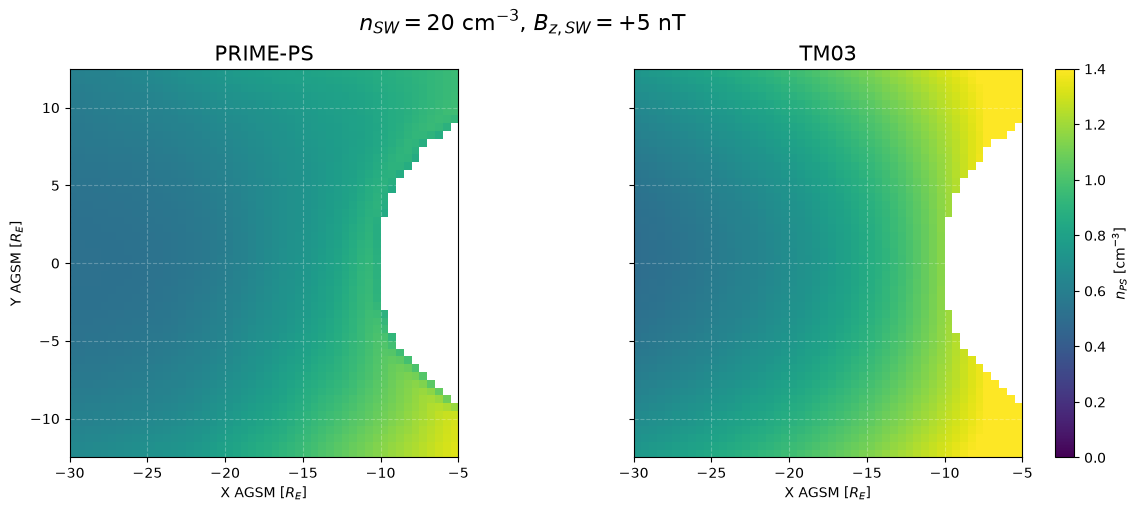

In [6]:
# Select one common solar-wind condition for both plasma-sheet models.
# Change this key to explore another stored condition.
DENSITY_CASE_KEY = "high_density_northward"  # 20 cm^-3 and +5 nT.

x_edges = results["x_edges_re"]
y_edges = results["y_edges_re"]
density_case_keys = results["density_case_keys"].astype(str).tolist()
density_case_lookup = {
    key: index for index, key in enumerate(density_case_keys)
}
if DENSITY_CASE_KEY not in density_case_lookup:
    raise KeyError(
        f"Unknown density case {DENSITY_CASE_KEY!r}; "
        f"choose from {density_case_keys}"
    )
density_case_index = density_case_lookup[DENSITY_CASE_KEY]
density_maps = {
    "PRIME-PS": results["density_prime_ps_cases_cm3"][density_case_index],
    "TM03": results["density_tm03_cases_cm3"][density_case_index],
}
n_sw = float(results["density_case_n_sw_cm3"][density_case_index])
bz = float(results["density_case_bz_nt"][density_case_index])
smoothing_sigma = float(results["smoothing_sigma_cells"])

if DENSITY_CASE_KEY == "high_density_northward" and (n_sw, bz) != (20.0, 5.0):
    raise ValueError("Unexpected synthetic driving condition")
if not all(grid.shape == (50, 50) for grid in density_maps.values()):
    raise ValueError("Unexpected density-grid shape")
print(f"selected density case: {DENSITY_CASE_KEY}")
print(f"available density cases: {', '.join(density_case_keys)}")

figure, axes = plt.subplots(
    1, 2, figsize=(12.2, 5.0), sharex=True, sharey=True,
    constrained_layout=True,
)
density_mesh = None
for axis, (model, grid) in zip(axes, density_maps.items()):
    density_mesh = axis.pcolormesh(  # Use one color scale for a direct comparison.
        x_edges, y_edges, grid, cmap="viridis",
        vmin=0.0, vmax=1.4, shading="flat",
    )
    axis.set_title(model, fontsize=15)
    axis.set_xlabel(r"X AGSM [$R_E$]")
    axis.set_aspect("equal")
    axis.grid(color="white", linestyle="--", alpha=0.25)
axes[0].set_ylabel(r"Y AGSM [$R_E$]")

colorbar = figure.colorbar(density_mesh, ax=axes, pad=0.02)
colorbar.set_label(r"$n_{PS}$ [cm$^{-3}$]")
figure.suptitle(
    rf"$n_{{SW}}={n_sw:.0f}$ cm$^{{-3}}$, "
    rf"$B_{{z,SW}}={bz:+.0f}$ nT",
    fontsize=16,
)
plt.show()

### What changed in the spatial structure?

PRIME-PS produces a stronger cross-tail, $Y$-dependent density structure
under this driving condition, while TM03 remains comparatively symmetric.
The enhanced structure is dawn-favoring and is consistent with prior
observations of plasma entry during northward IMF.

The maps are conditional model outputs, not independent observations across
every grid cell. Their physical interpretation remains limited by the
spacecraft coverage represented in the training archive, the synthetic
driver choice, the common mask, block averaging, and light smoothing.

## What these comparisons establish

Together, the figures illustrate two complementary questions. The
chronological comparison measures pointwise agreement on common held-out
observations. The grid comparison asks whether a fitted model produces a
physically interpretable global structure under a specified input state.
Better pointwise metrics do not automatically validate every spatial
feature, and a plausible spatial pattern does not replace held-out
observational evaluation.

## Try it yourself in Colab

1. Change the scatter limits from 0-12 to 0-19 keV and inspect how the sparse
   high-temperature tail changes the visual impression. Then ask which
   metrics would better expose performance for extremes—for example,
   tail-conditioned MAE/RMSE above a threshold chosen in advance, tail bias,
   or precision and recall for exceeding that threshold.
2. Rebuild the compact dataset with `--gaussian-sigma 0` after extending the
   preparation script, then compare raw block averages with the lightly
   smoothed map.
3. In the density-map cell, change `DENSITY_CASE_KEY` from
   `"high_density_northward"` ($n_{SW}=20\,\mathrm{cm}^{-3}$,
   $B_z=+5\,\mathrm{nT}$) to `"high_density_southward"`
   ($n_{SW}=20\,\mathrm{cm}^{-3}$, $B_z=-5\,\mathrm{nT}$) or
   `"low_density_northward"` ($n_{SW}=3\,\mathrm{cm}^{-3}$,
   $B_z=+5\,\mathrm{nT}$). The fourth stored option is
   `"low_density_southward"` ($n_{SW}=3\,\mathrm{cm}^{-3}$,
   $B_z=-5\,\mathrm{nT}$). Keep the same mask, grid, and color limits so
   the visual comparison remains controlled.

In [7]:
results_record = {
    "dataset_id": DATASET_ID,
    "bundle_sha256": bundle_sha256,
    "sample_count": int(len(observed)),
    "split": "chronological-final-20-percent-strict",
    "metrics": metrics,
    "map_condition": {
        "case_key": DENSITY_CASE_KEY,
        "n_sw_cm3": n_sw,
        "bz_nt": bz,
        "grid_shape": [50, 50],
        "shared_density_limits_cm3": [0.0, 1.4],
        "smoothing_sigma_cells": smoothing_sigma,
    },
    "training_run": False,
}
print("HELIO_RESULTS " + json.dumps(results_record, sort_keys=True))

HELIO_RESULTS {"bundle_sha256": "ed9392dcdc305f0275459efb52e3fd15e80fd0be9b76b7a1816b5177cf2ba604", "dataset_id": "plasma-sheet-prime-tm03", "map_condition": {"bz_nt": 5.0, "case_key": "high_density_northward", "grid_shape": [50, 50], "n_sw_cm3": 20.0, "shared_density_limits_cm3": [0.0, 1.4], "smoothing_sigma_cells": 1.0}, "metrics": {"PRIME-PS": {"mae_kev": 1.2199367605555969, "pearson_r": 0.7035105836833908, "r2": 0.38796029877417915, "rmse_kev": 1.6149556863232586}, "TM03": {"mae_kev": 1.3574474341531055, "pearson_r": 0.5555405642115565, "r2": 0.27095503944365684, "rmse_kev": 1.7625764732492557}}, "sample_count": 46595, "split": "chronological-final-20-percent-strict", "training_run": false}


## References

- Raptis, S., O'Brien, C., Sorathia, K., Merkin, V., Ohtani, S., Richard,
  L., Devanandan, A. P., and Wing, S., *Machine Learning Modeling of
  Earth's Plasma Sheet using Multi-Spacecraft Observations*, manuscript
  under review.
- O'Brien, C., Walsh, B. M., Zou, Y., Tasnim, S., Zhang, H., and Sibeck,
  D. G. (2023), [*PRIME: a probabilistic neural network approach to solar
  wind propagation from L1*](https://www.frontiersin.org/journals/astronomy-and-space-sciences/articles/10.3389/fspas.2023.1250779/full),
  Frontiers in Astronomy and Space Sciences, 10, 1250779.
- O'Brien, C., Walsh, B. M., Zou, Y., Qudsi, R., Tasnim, S., Zhang, H.,
  and Sibeck, D. G. (2024), [*PRIME-SH: A Data-Driven Probabilistic Model
  of Earth's Magnetosheath*](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2024JH000235),
  Journal of Geophysical Research: Machine Learning and Computation, 1(3),
  e2024JH000235.
- Tsyganenko, N. A., and Mukai, T. (2003), *Tail plasma sheet models
  derived from Geotail particle data*, Journal of Geophysical Research:
  Space Physics, 108(A3).